In [ ]:
import argparse
import glob
import os
import tensorflow.compat.v1 as tf

tf.disable_v2_behavior()
import numpy as np
import matplotlib.pyplot as plt

Instructions for updating:
non-resource variables are not supported in the long term


In [ ]:
def get_section_results(file):
    """
    Extracts training steps and average returns from TensorBoard logs.
    """
    X = []
    Y = []
    for e in tf.train.summary_iterator(file):
        for v in e.summary.value:
            if v.tag == "Train_EnvstepsSoFar":
                X.append(v.simple_value)
            elif v.tag == "Train_AverageReturn":
                Y.append(v.simple_value)
        if len(X) > 120:  # Limit the number of points to avoid very long plots
            break
    return X, Y

In [7]:
!ls ~/Desktop/TFs/hw3/

data


In [41]:
def plot_results(exp_name, label_name):
    logdir = os.path.join(
        "/Users/tommy/Desktop/TFs/hw3/data", f"{exp_name}*", "events*"
    )
    eventfiles = glob.glob(logdir)

    result = []
    for eventfile in eventfiles:
        X, Y = get_section_results(eventfile)
        result.append(Y)
    print(X)
    X = X[1:]
    mean = np.mean(np.array(result), axis=0)
    std = np.std(np.array(result), axis=0)

    plt.errorbar(X, mean, yerr=std, label=label_name, capsize=3)
    plt.xlabel("Steps")
    plt.ylabel("Average Return")
    plt.grid(True)

    plt.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))

[1.0, 10001.0, 20001.0, 30001.0, 40001.0, 50001.0, 60001.0, 70001.0, 80001.0, 90001.0, 100001.0, 110001.0, 120001.0, 130001.0, 140001.0, 150001.0, 160001.0, 170001.0, 180001.0, 190001.0, 200001.0, 210001.0, 220001.0, 230001.0, 240001.0, 250001.0, 260001.0, 270001.0, 280001.0, 290001.0, 300001.0]
[1.0, 10001.0, 20001.0, 30001.0, 40001.0, 50001.0, 60001.0, 70001.0, 80001.0, 90001.0, 100001.0, 110001.0, 120001.0, 130001.0, 140001.0, 150001.0, 160001.0, 170001.0, 180001.0, 190001.0, 200001.0, 210001.0, 220001.0, 230001.0, 240001.0, 250001.0, 260001.0, 270001.0, 280001.0, 290001.0, 300001.0]


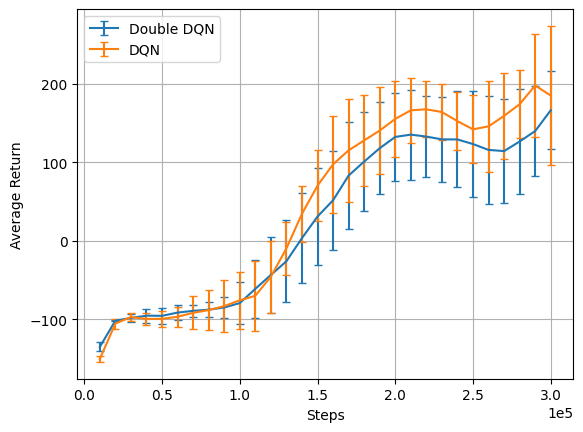

In [42]:
plot_results("q1_doubledqn", "Double DQN")
plot_results("q1_dqn", "DQN")
plt.legend()
plt.savefig("../../figures/q1.png")